# Stacking Ensemble Pipeline

**Architecture:** Raw features → Base Learners (OOF) → Meta-features → MLP Meta-Learner → Isotonic Calibration → ŷ

| Section | Contents |
|---|---|
| 1 | Setup & Imports |
| 2 | Configuration |
| 3 | Utilities |
| 4 | Feature Engineering |
| 5 | Data Loading & Preprocessing |
| 6 | Data Splitting |
| 7 | Hyperparameter Tuning (Optuna) |
| 8 | Ablation Study |
| 9 | Base Models |
| 10 | Meta-Model |
| 11 | Stacking Pipeline |
| 12 | Training |
| 13 | Evaluation |
| 14 | Visualisation |
| 15 | Save & JSON Log |


## 1. Setup & Imports

In [38]:
import json
import logging
import pickle
import sys
import time
import warnings
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    BaggingClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, cohen_kappa_score,
    confusion_matrix, f1_score, log_loss, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, learning_curve, train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna

warnings.filterwarnings("ignore")
%matplotlib inline

TS = datetime.now().strftime("%Y%m%d_%H%M%S")
PALETTE = [
    "#2196F3", "#4CAF50", "#FF5722", "#9C27B0", "#FF9800",
    "#00BCD4", "#F44336", "#3F51B5", "#8BC34A", "#795548",
    "#E91E63", "#009688",
]
print("Imports OK")

Imports OK


## 2. Configuration

Set all runtime options here — this replaces the CLI `argparse` arguments from the original script.

In [39]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH       = Path("dataset/processed/processed_data.csv")   # ← change to your CSV path
TARGET_COL      = "Output"
OUTPUT_DIR      = Path("artifacts")

# ── Split strategy ─────────────────────────────────────────────────────────────
SPLIT_STRATEGY  = "random"   # "random" | "temporal" | "site"
DATE_COL        = None       # column name for temporal split
SITE_COL        = None       # column name for site split
TEST_SIZE       = 0.20
VAL_SIZE        = 0.20

# ── Pipeline knobs ─────────────────────────────────────────────────────────────
N_SPLITS        = 5
META_EPOCHS     = 400
META_LR         = 5e-4
FEAT_MASK_FRAC  = 0.70
CLASS2_WEIGHT   = 1.5
USE_SMOTE       = True
FAST_MODE       = False     # True = lighter models, faster iteration

# ── Feature engineering ────────────────────────────────────────────────────────
RUN_FEATURE_ENG = True

# ── Optuna HPO ─────────────────────────────────────────────────────────────────
TUNE_TRIALS     = 50        # Optuna trials per model

# ── Ablation ───────────────────────────────────────────────────────────────────
RUN_ABLATION    = False     # set True to audit Race + evidence-score leakage

# ── Calibration ────────────────────────────────────────────────────────────────
RUN_CALIBRATION = True      # post-hoc isotonic OvR calibration

# ── Clinical domain constants ──────────────────────────────────────────────────
EVIDENCE_SCORE_COLS = ["dengue_evidence_score", "chik_evidence_score", "differential_score"]
RACE_COL            = "Race"
DURATION_COL        = "Number of days the patient is experiencing"
DW_COLS             = [
    "Fever_dw", "Headache_dw", "Retroorbital pain_dw", "Myalgia_dw",
    "Arthralgia_dw", "Arthritis_dw", "Rash_dw", "Nausea_dw", "Vomiting_dw",
    "Petechiae_dw", "Conjunctivitis_dw", "Back Pain_dw",
]

np.random.seed(42)
print("Configuration set.")

Configuration set.


## 3. Utilities

Directory setup, logger, and the stratified bootstrap index helper used in Phase 2 training.

In [40]:
def build_paths(output_dir: Path) -> dict:
    root = output_dir.resolve()
    dirs = {k: root / k for k in ("model", "logs", "charts")}
    dirs["root"] = root
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)
    return dirs


def build_logger(name: str, log_dir: Path) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(logging.DEBUG)
    logger.propagate = False
    if logger.handlers:
        logger.handlers.clear()
    fmt = logging.Formatter(
        "%(asctime)s  [%(levelname)-8s]  %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    fh = logging.FileHandler(log_dir / f"pipeline_{TS}.log", encoding="utf-8")
    fh.setFormatter(fmt)
    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(fh)
    logger.addHandler(sh)
    return logger


def stratified_bootstrap_indices(y: np.ndarray, rng: np.random.RandomState) -> np.ndarray:
    """Per-class stratified bootstrap — preserves class ratios in each bootstrap draw."""
    parts = []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        parts.append(rng.choice(idx, size=len(idx), replace=True))
    boot = np.concatenate(parts)
    rng.shuffle(boot)
    return boot


# Initialise paths and logger
paths = build_paths(OUTPUT_DIR)
log   = build_logger("stacking_nb", paths["logs"])
print(f"Artifacts root: {paths['root']}")

Artifacts root: C:\Users\Quoc Thai\Downloads\ML\HealthcareSystemForDengueFever\artifacts


## 5. Data Loading & Preprocessing

Loads the CSV, runs feature engineering, coerces types, imputes missing values with column medians, and encodes the target label.

In [41]:
log.info("Loading dataset …")
df = pd.read_csv(DATA_PATH)
assert TARGET_COL in df.columns, f"Target '{TARGET_COL}' not found. Columns: {list(df.columns)}"

feat_cols = [c for c in df.columns if c != TARGET_COL]
X_df = df[feat_cols].copy()

# Type coercion & median imputation
for col in X_df.columns:
    if X_df[col].dtype == bool:
        X_df[col] = X_df[col].astype(int)
X_df = X_df.apply(pd.to_numeric, errors="coerce")

X     = X_df.values.astype(np.float32)
y_raw = df[TARGET_COL].values
le    = LabelEncoder()
y     = le.fit_transform(y_raw)
n_cl  = len(np.unique(y))

counts = {int(c): int((y == c).sum()) for c in np.unique(y)}
log.info(f"  Dataset  : {X.shape[0]} rows × {X.shape[1]} features")
log.info(f"  Classes  : {list(np.unique(y_raw))} → {list(np.unique(y))}")
log.info(f"  Counts   : {counts}")

# Quick class-balance summary
pd.Series(counts, name="count").rename_axis("class")

2026-04-10 23:08:32  [INFO    ]  Loading dataset …
2026-04-10 23:08:32  [INFO    ]    Dataset  : 16126 rows × 28 features
2026-04-10 23:08:32  [INFO    ]    Classes  : [np.int64(0), np.int64(1), np.int64(2)] → [np.int64(0), np.int64(1), np.int64(2)]
2026-04-10 23:08:32  [INFO    ]    Counts   : {0: 5414, 1: 5420, 2: 5292}


class
0    5414
1    5420
2    5292
Name: count, dtype: int64

## 6. Data Splitting

Supports three strategies controlled by `SPLIT_STRATEGY`:
- **`random`** — stratified random 60/20/20 split *(default)*
- **`temporal`** — sort by `DATE_COL`, hold out the last rows chronologically
- **`site`** — hold out all rows from one hospital/site (`SITE_COL`) as the test set

In [42]:
def make_split(X, y, df_raw, feat_cols):
    temp_size = TEST_SIZE + VAL_SIZE
    rel_test  = TEST_SIZE / temp_size

    if SPLIT_STRATEGY == "temporal" and DATE_COL and DATE_COL in df_raw.columns:
        log.info(f"  Split strategy: TEMPORAL (sort by '{DATE_COL}')")
        order     = df_raw[DATE_COL].argsort().values
        X_s, y_s  = X[order], y[order]
        n         = len(y_s)
        n_hold    = max(2, int(np.ceil(n * temp_size)))
        n_val     = max(1, int(np.ceil(n_hold * (1 - rel_test))))
        n_te      = n_hold - n_val
        return (X_s[:n-n_hold], X_s[n-n_hold:n-n_te], X_s[n-n_te:],
                y_s[:n-n_hold], y_s[n-n_hold:n-n_te], y_s[n-n_te:])

    if SPLIT_STRATEGY == "site" and SITE_COL and SITE_COL in df_raw.columns:
        log.info(f"  Split strategy: SITE (hold out first site in '{SITE_COL}')")
        holdout = df_raw[SITE_COL].unique()[0]
        te_mask = df_raw[SITE_COL].values == holdout
        X_rest, y_rest = X[~te_mask], y[~te_mask]
        X_te,   y_te   = X[te_mask],  y[te_mask]
        val_frac = VAL_SIZE / (1 - TEST_SIZE)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_rest, y_rest, test_size=val_frac, stratify=y_rest, random_state=42)
        return X_tr, X_val, X_te, y_tr, y_val, y_te

    # Default: random stratified
    log.info("  Split strategy: RANDOM (stratified)")
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=42)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=rel_test, stratify=y_tmp, random_state=42)
    return X_tr, X_val, X_te, y_tr, y_val, y_te


X_tr, X_val, X_te, y_tr, y_val, y_te = make_split(X, y, df, feat_cols)
log.info(f"  Train: {len(y_tr)}  Val: {len(y_val)}  Test: {len(y_te)}")

2026-04-10 23:08:32  [INFO    ]    Split strategy: RANDOM (stratified)
2026-04-10 23:08:32  [INFO    ]    Train: 9675  Val: 3225  Test: 3226


## 7. Hyperparameter Tuning (Optuna)

TPE Bayesian search over **RandomForest** and **HistGradientBoosting** hyperparameters, optimising macro F1 via the same `StratifiedKFold` used in the main pipeline.

Controlled by `RUN_TUNING` and `TUNE_TRIALS` in the Configuration cell. Best parameters are automatically injected into the pipeline below.

In [43]:
def tune_hyperparameters(X_train, y_train):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    def _cv_f1(clf):
        return float(cross_val_score(clf, X_train, y_train,
                                     cv=skf, scoring="f1_macro", n_jobs=-1).mean())

    # RandomForest study
    log.info(f"  [Optuna] Tuning RandomForest ({TUNE_TRIALS} trials) …")
    def rf_objective(trial):
        return _cv_f1(RandomForestClassifier(
            n_estimators     = trial.suggest_int("n_estimators", 80, 300),
            max_depth        = trial.suggest_int("max_depth", 6, 16),
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 10),
            max_features     = trial.suggest_float("max_features", 0.3, 0.8),
            class_weight="balanced", n_jobs=-1, random_state=42,
        ))
    rf_study = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=42))
    rf_study.optimize(rf_objective, n_trials=TUNE_TRIALS, show_progress_bar=True)
    log.info(f"    Best RF: {rf_study.best_params}  F1={rf_study.best_value:.4f}")

    # HistGradientBoosting study
    log.info(f"  [Optuna] Tuning HistGradientBoosting ({TUNE_TRIALS} trials) …")
    def histgb_objective(trial):
        return _cv_f1(HistGradientBoostingClassifier(
            max_iter          = trial.suggest_int("max_iter", 60, 300),
            max_depth         = trial.suggest_int("max_depth", 3, 8),
            learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 10, 50),
            l2_regularization = trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
            random_state=42,
        ))
    hgb_study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=43))
    hgb_study.optimize(histgb_objective, n_trials=TUNE_TRIALS, show_progress_bar=True)
    log.info(f"    Best HistGB: {hgb_study.best_params}  F1={hgb_study.best_value:.4f}")

    return {"rf": rf_study.best_params, "histgb": hgb_study.best_params}


tuned_params = {"rf": {}, "histgb": {}}
tuned_params = tune_hyperparameters(X_tr, y_tr)
print("Tuned RF params    :", tuned_params["rf"])
print("Tuned HistGB params:", tuned_params["histgb"])

2026-04-10 23:08:32  [INFO    ]    [Optuna] Tuning RandomForest (50 trials) …


[I 2026-04-10 23:08:32,173] A new study created in memory with name: no-name-92d47361-a37f-4079-976a-64527c514a8a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-10 23:08:35,171] Trial 0 finished with value: 0.6030541047819888 and parameters: {'n_estimators': 162, 'max_depth': 16, 'min_samples_leaf': 8, 'max_features': 0.5993292420985183}. Best is trial 0 with value: 0.6030541047819888.
[I 2026-04-10 23:08:37,347] Trial 1 finished with value: 0.5987561535850874 and parameters: {'n_estimators': 114, 'max_depth': 7, 'min_samples_leaf': 2, 'max_features': 0.7330880728874676}. Best is trial 0 with value: 0.6030541047819888.
[I 2026-04-10 23:08:40,354] Trial 2 finished with value: 0.5918605903156215 and parameters: {'n_estimators': 212, 'max_depth': 13, 'min_samples_leaf': 2, 'max_features': 0.7849549260809972}. Best is trial 0 with value: 0.6030541047819888.
[I 2026-04-10 23:08:42,812] Trial 3 finished with value: 0.5996342380432168 and parameters: {'n_estimators': 263, 'max_depth': 8, 'min_samples_leaf': 3, 'max_features': 0.3917022549267169}. Best is trial 0 with value: 0.6030541047819888.
[I 2026-04-10 23:08:43,476] Trial 4 finished w

[I 2026-04-10 23:09:22,656] A new study created in memory with name: no-name-fa1cafd8-5eeb-4661-8e85-494cf7cf091d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-10 23:09:23,476] Trial 0 finished with value: 0.6017082072119739 and parameters: {'max_iter': 87, 'max_depth': 6, 'learning_rate': 0.014912334799978505, 'min_samples_leaf': 19, 'l2_regularization': 0.0020349616224981555}. Best is trial 0 with value: 0.6017082072119739.
[I 2026-04-10 23:09:25,181] Trial 1 finished with value: 0.6005399794212269 and parameters: {'max_iter': 267, 'max_depth': 6, 'learning_rate': 0.050590418343363905, 'min_samples_leaf': 11, 'l2_regularization': 0.08609802417157009}. Best is trial 0 with value: 0.6017082072119739.
[I 2026-04-10 23:09:26,489] Trial 2 finished with value: 0.6029090198051643 and parameters: {'max_iter': 155, 'max_depth': 7, 'learning_rate': 0.021429375567205422, 'min_samples_leaf': 12, 'l2_regularization': 0.2928158381299606}. Best is trial 2 with value: 0.6029090198051643.
[I 2026-04-10 23:09:27,348] Trial 3 finished with value: 0.5998841062980451 and parameters: {'max_iter': 113, 'max_depth': 5, 'learning_rate': 0.025778105117671

## 8. Ablation Study

Trains a RandomForest proxy under four feature configurations to audit:
- **`no_race`** — does removing `Race` meaningfully change macro F1? (>0.5% = investigate)
- **`no_evid`** — does removing the three `*_evidence_score` columns cause a large drop? (>5% = likely leakage)

Set `RUN_ABLATION = True` in Configuration to activate.

In [44]:
def run_ablation(X, y, feat_cols):
    log.info("=" * 60)
    log.info("  ABLATION STUDY  (Race + evidence scores)")
    log.info("=" * 60)

    skf   = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    proxy = RandomForestClassifier(
        n_estimators=147, max_depth=11, min_samples_leaf=5,
        max_features=0.4456, class_weight="balanced",
        n_jobs=-1, random_state=42,
    )
    race_mask = np.array([c != RACE_COL for c in feat_cols])
    evid_mask = np.array([c not in EVIDENCE_SCORE_COLS for c in feat_cols])
    configs = {
        "full"     : np.ones(len(feat_cols), dtype=bool),
        "no_race"  : race_mask,
        "no_evid"  : evid_mask,
        "core_only": race_mask & evid_mask,
    }
    results = {}
    for name, mask in configs.items():
        f1 = float(cross_val_score(deepcopy(proxy), X[:, mask], y,
                                   cv=skf, scoring="f1_macro", n_jobs=-1).mean())
        results[name] = {"f1_macro": f1, "n_features": int(mask.sum())}
        log.info(f"  {name:<12}  n_feat={mask.sum():3d}  macro F1 = {f1:.4f}")

    baseline     = results["full"]["f1_macro"]
    evid_drop    = baseline - results["no_evid"]["f1_macro"]
    race_impact  = abs(results["no_race"]["f1_macro"] - baseline)

    log.info("\n  Delta vs full-feature baseline:")
    for k, v in results.items():
        log.info(f"    {k:<12}  ΔF1 = {v['f1_macro'] - baseline:+.4f}")

    if evid_drop > 0.05:
        log.warning(f"  ⚠  Evidence scores drop F1 by {evid_drop:.3f} — verify for leakage!")
    else:
        log.info(f"  ✔  Evidence score impact = {evid_drop:.3f} (<5%). Safe to retain.")

    if race_impact < 0.005:
        log.info("  ✔  Race negligible (<0.5% F1). Consider dropping.")
    else:
        log.info(f"  ⚠  Race contributes {race_impact:.3f} F1. Investigate.")

    return results


ablation_results = {}
ablation_results = run_ablation(X_tr, y_tr, feat_cols)

2026-04-10 23:10:25  [INFO    ]  ============================================================
2026-04-10 23:10:25  [INFO    ]    ABLATION STUDY  (Race + evidence scores)
2026-04-10 23:10:25  [INFO    ]  ============================================================
2026-04-10 23:10:26  [INFO    ]    full          n_feat= 28  macro F1 = 0.6001
2026-04-10 23:10:27  [INFO    ]    no_race       n_feat= 27  macro F1 = 0.5881
2026-04-10 23:10:27  [INFO    ]    no_evid       n_feat= 25  macro F1 = 0.6002
2026-04-10 23:10:28  [INFO    ]    core_only     n_feat= 24  macro F1 = 0.5888
2026-04-10 23:10:28  [INFO    ]  
  Delta vs full-feature baseline:
2026-04-10 23:10:28  [INFO    ]      full          ΔF1 = +0.0000
2026-04-10 23:10:28  [INFO    ]      no_race       ΔF1 = -0.0120
2026-04-10 23:10:28  [INFO    ]      no_evid       ΔF1 = +0.0002
2026-04-10 23:10:28  [INFO    ]      core_only     ΔF1 = -0.0113
2026-04-10 23:10:28  [INFO    ]    ✔  Evidence score impact = -0.000 (<5%). Safe to retain.


## 9. Base Models

Ten architecturally diverse learners covering three major algorithmic families:

| # | Model | Family | Notes |
|---|---|---|---|
| 1 | RandomForest | Bagging | Optuna-tuned |
| 2 | GradientBoosting | Boosting (depth-wise) | sklearn, depth-3 |
| 3 | HistGradientBoosting | Boosting (histogram) | Optuna-tuned |
| 4 | CalibratedPolyLR | Linear | Degree-2 interactions + L2 logistic |
| 5 | Bagging_DT | Bagging | Decision tree bags |
| 6 | SVM_RBF | Kernel | Sigmoid-calibrated |
| 7 | LightGBM | Boosting (leaf-wise) | Requires `pip install lightgbm` |
| 8 | CatBoost | Boosting (ordered) | Requires `pip install catboost` |

Each model receives a **random 70% feature subset** (see `_assign_feature_masks`) to enforce diversity in the meta-feature space.
Phase 2 final models are trained on **stratified bootstrap samples** rather than the full training set.

In [45]:
def build_base_learners(rf_params: dict = None, histgb_params: dict = None,
                        fast: bool = False, random_state: int = 42) -> dict:
    """
    Returns the ordered dict of base learner instances.
    rf_params / histgb_params override defaults (used when Optuna tuning ran).
    """
    rs    = random_state
    gb_n  = 50  if fast else 80
    bag_n = 40  if fast else 60
    mlp_i = 120 if fast else 300

    # ── RandomForest (Optuna-tuned defaults) ─────────────────────────────────
    rf_kw = dict(n_estimators=147, max_depth=11, min_samples_leaf=5,
                 max_features=0.4456, class_weight="balanced",
                 n_jobs=-1, random_state=rs)
    if rf_params:
        rf_kw.update(rf_params)

    # ── HistGradientBoosting (Optuna-tuned defaults) ─────────────────────────
    hgb_kw = dict(max_iter=166, max_depth=6,
                  learning_rate=0.04145, min_samples_leaf=30,
                  l2_regularization=0.01103, random_state=rs)
    if histgb_params:
        hgb_kw.update(histgb_params)

    learners = {
        "RandomForest": RandomForestClassifier(**rf_kw),

        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=gb_n, learning_rate=0.05, max_depth=3,
            subsample=0.8, max_features="sqrt", random_state=rs,
        ),

        "HistGradientBoosting": HistGradientBoostingClassifier(**hgb_kw),

        "CalibratedPolyLR": CalibratedClassifierCV(
            estimator=Pipeline([
                ("poly",   PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
                ("scaler", StandardScaler()),
                ("lr",     LogisticRegression(C=0.1, penalty="l2", solver="lbfgs",
                                              max_iter=1000, class_weight="balanced",
                                              random_state=rs)),
            ]),
            cv=3, method="sigmoid",
        ),

        "Bagging_DT": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=7, min_samples_leaf=3, random_state=rs),
            n_estimators=bag_n, max_samples=0.8, max_features=0.8,
            n_jobs=-1, random_state=rs,
        ),

        "SVM_RBF": CalibratedClassifierCV(
            estimator=SVC(kernel="rbf", C=10.0, gamma="scale",
                          class_weight="balanced", probability=False),
            cv=3, method="sigmoid",
        ),
        "XGBoost": XGBClassifier(
            n_estimators=gb_n, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, tree_method="hist",
            eval_metric="mlogloss", use_label_encoder=False,
            n_jobs=-1, random_state=rs, verbosity=0,
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=gb_n, max_depth=5, learning_rate=0.05,
            num_leaves=31, min_child_samples=20, subsample=0.8,
            colsample_bytree=0.8, class_weight="balanced",
            n_jobs=-1, random_state=rs, verbose=-1,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=gb_n, depth=6, learning_rate=0.05,
            l2_leaf_reg=3, random_seed=rs, verbose=0,
            auto_class_weights="Balanced",
        )
    }

    print(f"Base learners defined: {list(learners.keys())}")
    return learners

## 10. Meta-Model

### 10a. MLP Meta-Learner
A 2-hidden-layer MLP (`n_meta_features → 64 → 32 → n_classes`) trained on the OOF meta-features. Uses Adam, L2 regularisation, class-weighted loss, and early stopping.

### 10b. Post-hoc Isotonic Calibration
One `IsotonicRegression` calibrator is fitted per class (OvR) on the validation-set meta-features. Probabilities are renormalised to a valid simplex after calibration.

### 10c. Sklearn Wrapper
Thin wrapper exposing the full pipeline to `sklearn.inspection.permutation_importance`.

In [46]:
class MLPMetaWrapper:
    """
    Wraps sklearn MLPClassifier as the stacking meta-learner.
    Architecture: n_meta_features → 64 (ReLU) → 32 (ReLU) → n_classes (Softmax)

    Exposes for plotting compatibility
    ----------------------------------
    loss_history     : training loss per epoch (loss_curve_)
    val_loss_history : 1 − val_accuracy per epoch
    W                : first-layer weights (n_meta_features, 64)
    """
    def __init__(self, n_classes=3, hidden_layer_sizes=(64, 32), lr=1e-3,
                 epochs=300, batch_size=256, lambda_l2=1e-4, patience=20,
                 class_weights=None, random_state=42):
        self.n_classes     = n_classes
        self.class_weights = np.ones(n_classes) if class_weights is None \
                             else np.asarray(class_weights, dtype=float)
        self._mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes, activation="relu",
            solver="adam", alpha=lambda_l2, batch_size=min(batch_size, 128),
            learning_rate_init=lr, max_iter=epochs,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=patience, random_state=random_state,
        )
        self.loss_history     = []
        self.val_loss_history = []
        self.W                = None

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self._mlp.fit(X_train, y_train,
                      sample_weight=self.class_weights[y_train])
        self.loss_history = list(self._mlp.loss_curve_)
        if hasattr(self._mlp, "validation_scores_") and self._mlp.validation_scores_:
            self.val_loss_history = [1.0 - s for s in self._mlp.validation_scores_]
        self.W = self._mlp.coefs_[0]   # first-layer weights
        return self

    def predict_proba(self, X): return self._mlp.predict_proba(X)
    def predict(self, X):       return self._mlp.predict(X)


class CalibratedMetaWrapper:
    """
    Post-hoc OvR isotonic calibration on top of MLPMetaWrapper.
    Forwards loss_history, val_loss_history, and W transparently.
    """
    def __init__(self, meta_learner, method="isotonic"):
        self._meta        = meta_learner
        self._method      = method
        self._calibrators = None
        self.loss_history     = meta_learner.loss_history
        self.val_loss_history = meta_learner.val_loss_history
        self.W                = meta_learner.W

    def fit_calibration(self, X_val_meta, y_val, n_classes):
        raw = self._meta.predict_proba(X_val_meta)
        self._calibrators = []
        for c in range(n_classes):
            y_bin = (y_val == c).astype(int)
            cal   = IsotonicRegression(out_of_bounds="clip") if self._method == "isotonic" \
                    else LogisticRegression(C=1.0, solver="lbfgs", max_iter=500)
            if self._method == "isotonic":
                cal.fit(raw[:, c], y_bin)
            else:
                cal.fit(raw[:, c].reshape(-1, 1), y_bin)
            self._calibrators.append(cal)
        return self

    def _calibrate(self, raw):
        if self._calibrators is None:
            return raw
        cal = np.zeros_like(raw)
        for c, calibrator in enumerate(self._calibrators):
            cal[:, c] = calibrator.predict(raw[:, c]) if self._method == "isotonic" \
                        else calibrator.predict_proba(raw[:, c].reshape(-1, 1))[:, 1]
        row_sums = np.where(cal.sum(1, keepdims=True) == 0, 1.0, cal.sum(1, keepdims=True))
        return cal / row_sums

    def predict_proba(self, X): return self._calibrate(self._meta.predict_proba(X))
    def predict(self, X):       return self.predict_proba(X).argmax(axis=1)


class SklearnPipelineWrapper(BaseEstimator, ClassifierMixin):
    """Thin sklearn-compatible wrapper for permutation importance."""
    def __init__(self, pipe): self.pipe = pipe
    def fit(self, X, y):      return self
    def predict(self, X):     return self.pipe.predict(X)
    def score(self, X, y):    return accuracy_score(y, self.predict(X))


print("Meta-model classes defined.")

Meta-model classes defined.


## 11. Stacking Pipeline

The `StackingPipeline` class orchestrates three training phases:

```
Phase 1 — OOF meta-features
    For each base learner:
        For each CV fold:  fit on (train fold + SMOTE)  →  predict OOF & val
        Average val predictions across folds (same epistemic quality as OOF)

Phase 2 — Final base learners
    For each base learner:
        Draw stratified bootstrap sample  →  apply SMOTE  →  fit

Phase 3 — Meta-learner
    Scale OOF / val meta-features  →  train MLP (64→32)  →  optional isotonic calibration
```

In [47]:
class StackingPipeline:

    def __init__(self, logger, n_splits=5, random_state=42, meta_epochs=300,
                 meta_lr=1e-3, scale_features=True, feat_mask_frac=0.70,
                 use_smote=True, class2_weight=1.5, fast=False,
                 rf_params=None, histgb_params=None, disable_calibration=False):
        self.log                = logger
        self.n_splits           = n_splits
        self.random_state       = random_state
        self.meta_epochs        = meta_epochs
        self.meta_lr            = meta_lr
        self.scale_features     = scale_features
        self.feat_mask_frac     = feat_mask_frac
        self.use_smote          = use_smote
        self.class2_weight      = class2_weight
        self.fast               = fast
        self.rf_params          = rf_params or {}
        self.histgb_params      = histgb_params or {}
        self.disable_calibration= disable_calibration

        self.scaler      = StandardScaler()
        self.meta_scaler = StandardScaler()
        self.skf         = StratifiedKFold(n_splits=n_splits, shuffle=True,
                                           random_state=random_state)
        self.feature_names        = None
        self.classes_             = None
        self.n_classes_           = None
        self.feature_masks        = {}
        self.fitted_base_learners = {}
        self.bootstrap_indices    = {}
        self.train_metrics        = {}
        self.eval_metrics         = {}
        self.perm_importances     = None
        self.perm_importances_std = None
        self.fold_scores          = []
        self.meta_learner         = None
        self.base_learners        = build_base_learners(
            rf_params, histgb_params, fast, random_state)

    # ── internal helpers ─────────────────────────────────────────────────────
    def _assign_feature_masks(self, n_features, feat_cols=None):
        """
        Assign a tailored feature subset to each base learner based on its
        inductive bias rather than drawing a random 70% slice for every model.

        Feature groups (derived from clinical column naming conventions):
          raw_dw       — binary symptom×duration indicators  (*_dw columns)
          evidence     — clinical evidence scores            (*_evidence_score, differential_score)
          composites   — engineered syndrome composite sums  (composite_*)
          interactions — pairwise symptom interaction terms  (ix_*)
          dur_ints     — duration × symptom interaction terms (dur_x_*)
          demographic  — patient demographics                (Race)
          duration     — raw illness duration                (contains "days")
          other        — any remaining numeric features

        Model-to-feature rationale
        --------------------------
        RandomForest       Raw symptoms + evidence + composites + duration.
                           Tree bagging benefits from clean discriminative signals;
                           engineered interactions add collinearity without gain.
        GradientBoosting   Raw symptoms + evidence + duration + demographics.
                           Shallow depth-3 trees; simpler features generalise better.
        HistGradientBoosting  Raw symptoms + composites + duration interactions.
                           Deeper histogram boosting can exploit pre-built interactions
                           without the collinearity risk faced by linear models.
        CalibratedPolyLR   Raw symptoms + evidence + duration + demographics ONLY.
                           This model generates its own degree-2 polynomial features
                           internally; feeding it engineered interactions creates severe
                           multicollinearity and inflates the polynomial feature space.
        Bagging_DT         Interaction terms + composites + duration interactions.
                           Depth-7 trees actively benefit from pre-multiplied interactions
                           and composite scores; avoids overlapping with RF.
        SVM_RBF            Evidence + composites + duration interactions.
                           Kernel SVM works best on compact continuous/dense signals;
                           sparse binary symptom flags degrade RBF kernel distances.
        XGBoost            Raw symptoms + interaction terms + duration interactions.
                           Second-order gradients excel at learning from interaction
                           structure; raw symptoms provide discriminative leaf splits.
        LightGBM           Raw symptoms + composites + duration + interactions.
                           Leaf-wise growth handles many features efficiently; the mix
                           of composites and raw signals maximises the feature diversity
                           contribution relative to the other boosters.
        CatBoost           Demographics + raw symptoms + evidence + composites.
                           Ordered boosting is particularly robust with categorical
                           features (Race) alongside continuous clinical signals.
        """
        if feat_cols is None:
            # Fallback: original random-subspace behaviour
            rng = np.random.RandomState(self.random_state)
            k   = max(1, int(round(self.feat_mask_frac * n_features)))
            for name in self.base_learners:
                self.feature_masks[name] = np.sort(
                    rng.choice(n_features, size=k, replace=False))
            self.log.info(f"  Feature masks (random fallback): {k}/{n_features} per model")
            return

        col_arr = np.array(feat_cols)

        # ── Group features by naming convention ─────────────────────────────
        def idx_of(mask_bool):
            """Return sorted integer indices where mask_bool is True."""
            return np.where(mask_bool)[0]

        raw_dw_idx    = idx_of(np.array([c.endswith("_dw") for c in col_arr]))
        evidence_idx  = idx_of(np.array([
            c in ("dengue_evidence_score", "chik_evidence_score", "differential_score")
            for c in col_arr]))
        composite_idx = idx_of(np.array([c.startswith("composite_") for c in col_arr]))
        interaction_idx = idx_of(np.array([c.startswith("ix_") for c in col_arr]))
        dur_int_idx   = idx_of(np.array([c.startswith("dur_x_") for c in col_arr]))
        demographic_idx = idx_of(np.array([c == "Race" for c in col_arr]))
        duration_idx  = idx_of(np.array(["days" in c.lower() for c in col_arr]))

        # "other" = anything that doesn't fall into the above groups
        labelled = (
            set(raw_dw_idx.tolist()) | set(evidence_idx.tolist()) |
            set(composite_idx.tolist()) | set(interaction_idx.tolist()) |
            set(dur_int_idx.tolist()) | set(demographic_idx.tolist()) |
            set(duration_idx.tolist())
        )
        other_idx = np.array([i for i in range(n_features) if i not in labelled])

        def merge(*groups):
            """Combine index arrays and sort, keeping only valid indices."""
            combined = np.concatenate([g for g in groups if len(g) > 0])
            return np.unique(combined)

        # ── Per-model tailored feature sets ─────────────────────────────────
        recipe = {
            # Raw discriminative signals + clinical scores + duration
            "RandomForest": merge(
                raw_dw_idx, evidence_idx, composite_idx, duration_idx, other_idx),

            # Simple interpretable features for shallow trees
            "GradientBoosting": merge(
                raw_dw_idx, evidence_idx, duration_idx, demographic_idx, other_idx),

            # Deeper boosting — benefits from pre-built interactions
            "HistGradientBoosting": merge(
                raw_dw_idx, composite_idx, dur_int_idx, other_idx),

            # Linear model with internal poly expansion — raw only, no collinearity
            "CalibratedPolyLR": merge(
                raw_dw_idx, evidence_idx, duration_idx, demographic_idx),

            # Deep bags benefit from interaction + composite features
            "Bagging_DT": merge(
                interaction_idx, composite_idx, dur_int_idx, evidence_idx),

            # Kernel SVM: compact continuous signals, avoid sparse binary
            "SVM_RBF": merge(
                evidence_idx, composite_idx, dur_int_idx, duration_idx),

            # XGBoost: interaction structure + raw signals
            "XGBoost": merge(
                raw_dw_idx, interaction_idx, dur_int_idx, other_idx),

            # LightGBM: broad mix for leaf-wise diversity
            "LightGBM": merge(
                raw_dw_idx, composite_idx, duration_idx, interaction_idx),

            # CatBoost: categorical-friendly + clinical scores
            "CatBoost": merge(
                demographic_idx, raw_dw_idx, evidence_idx, composite_idx),
        }

        min_features = 3  # safety floor: every model needs at least 3 features
        for name in self.base_learners:
            assigned = recipe.get(name)
            if assigned is None or len(assigned) < min_features:
                # Unknown model name or empty group — fall back to random subset
                rng = np.random.RandomState(self.random_state)
                k   = max(min_features, int(round(self.feat_mask_frac * n_features)))
                assigned = np.sort(rng.choice(n_features, size=k, replace=False))
                self.log.warning(
                    f"  ⚠  {name}: no feature recipe found or too few features "
                    f"({len(assigned if assigned is not None else [])}); "
                    f"using random {k}/{n_features} fallback."
                )
            self.feature_masks[name] = assigned

        # ── Logging summary ─────────────────────────────────────────────────
        self.log.info("  Feature masks (model-targeted):")
        group_labels = {
            "raw_dw": len(raw_dw_idx), "evidence": len(evidence_idx),
            "composites": len(composite_idx), "interactions": len(interaction_idx),
            "dur_ints": len(dur_int_idx), "demographic": len(demographic_idx),
            "duration": len(duration_idx), "other": len(other_idx),
        }
        self.log.info(f"    Feature groups: { {k: v for k, v in group_labels.items() if v > 0} }")
        for name, mask in self.feature_masks.items():
            self.log.info(f"    {name:<25} → {len(mask):3d} features")

    def _apply_smote(self, X_fold, y_fold):
        if not self.use_smote:
            return X_fold, y_fold
        binc = np.bincount(y_fold); binc = binc[binc > 0]
        if len(binc) < 2: return X_fold, y_fold
        k_nb = min(5, int(binc.min()) - 1)
        if k_nb < 1: return X_fold, y_fold
        return SMOTE(k_neighbors=k_nb,
                     random_state=self.random_state).fit_resample(X_fold, y_fold)

    def _get_meta_features(self, Xs):
        n_cl = self.n_classes_
        meta = np.zeros((Xs.shape[0],
                         len(self.fitted_base_learners) * n_cl), dtype=float)
        for idx, (name, clf) in enumerate(self.fitted_base_learners.items()):
            meta[:, idx*n_cl:(idx+1)*n_cl] = clf.predict_proba(
                Xs[:, self.feature_masks[name]])
        return meta

    # ── Phase 1 + 2 + 3 ─────────────────────────────────────────────────────
    def forward(self, X_train, y_train, X_val, y_val):
        """Full training forward pass (all three phases)."""
        self.log.info("=" * 60)
        self.log.info("  FORWARD PASS")
        self.log.info("=" * 60)
        t0 = time.time()
        n_train, n_feat = X_train.shape
        n_cl = self.n_classes_

        class_weights = np.ones(n_cl)
        if n_cl > 2:
            class_weights[2] = self.class2_weight
        self.meta_learner = MLPMetaWrapper(
            n_classes=n_cl, hidden_layer_sizes=(64, 32),
            lr=self.meta_lr, epochs=self.meta_epochs,
            lambda_l2=1e-4, patience=30,
            class_weights=class_weights, random_state=self.random_state,
        )

        Xs  = self.scaler.fit_transform(X_train) if self.scale_features else X_train
        Xvs = self.scaler.transform(X_val)       if self.scale_features else X_val
        self._assign_feature_masks(n_feat, feat_cols=self.feature_names)

        n_bl       = len(self.base_learners)
        oof_meta   = np.zeros((n_train, n_bl * n_cl), dtype=float)
        vfp        = {nm: np.zeros((Xvs.shape[0], n_cl)) for nm in self.base_learners}

        # Phase 1: OOF
        self.log.info("\n[Phase 1] OOF meta-features …")
        for bi, (name, clf) in enumerate(self.base_learners.items()):
            self.log.info(f"  ▸ {name}")
            mask  = self.feature_masks[name]
            oof_bl= np.zeros((n_train, n_cl))
            accs  = []
            for tr_i, va_i in self.skf.split(Xs, y_train):
                Xtr, ytr = self._apply_smote(Xs[tr_i][:, mask], y_train[tr_i])
                clf_f    = deepcopy(clf)
                clf_f.fit(Xtr, ytr)
                oof_bl[va_i] = clf_f.predict_proba(Xs[va_i][:, mask])
                vfp[name]   += clf_f.predict_proba(Xvs[:, mask])
                accs.append(accuracy_score(y_train[va_i], clf_f.predict(Xs[va_i][:, mask])))
            oof_meta[:, bi*n_cl:(bi+1)*n_cl] = oof_bl
            vfp[name] /= self.n_splits
            fm, fs = float(np.mean(accs)), float(np.std(accs))
            self.fold_scores.append({"model": name, "cv_mean": fm, "cv_std": fs})
            self.log.info(f"    CV Acc: {fm:.4f} ± {fs:.4f}")

        val_meta = np.zeros((Xvs.shape[0], n_bl * n_cl))
        for bi, nm in enumerate(self.base_learners):
            val_meta[:, bi*n_cl:(bi+1)*n_cl] = vfp[nm]

        # Phase 2: final base learners on stratified bootstrap
        self.log.info("\n[Phase 2] Final base learners (stratified bootstrap) …")
        for bi, (name, clf) in enumerate(self.base_learners.items()):
            self.log.info(f"  ▸ {name}")
            mask    = self.feature_masks[name]
            rng     = np.random.RandomState(self.random_state + bi)
            boot    = stratified_bootstrap_indices(y_train, rng)
            self.bootstrap_indices[name] = boot
            Xb, yb  = self._apply_smote(Xs[boot][:, mask], y_train[boot])
            fitted  = deepcopy(clf)
            fitted.fit(Xb, yb)
            self.fitted_base_learners[name] = fitted

        # Phase 3: meta-learner
        self.log.info("\n[Phase 3] Training MLP meta-learner (64→32) …")
        oof_s = self.meta_scaler.fit_transform(oof_meta)
        val_s = self.meta_scaler.transform(val_meta)
        self.backward(oof_s, y_train, val_s, y_val)

        self.log.info(f"\n  ✔  Forward pass in {(time.time()-t0)/60:.1f} min")
        return self

    def backward(self, X_meta_train, y_train, X_meta_val, y_val):
        """Train the MLP meta-learner via Adam (wrapped by sklearn)."""
        self.log.info(f"  Meta MLP  lr={self.meta_lr}  epochs={self.meta_epochs}  hidden=(64,32)")
        self.meta_learner.fit(X_meta_train, y_train, X_meta_val, y_val)
        self.train_metrics["meta_train_acc"] = float(
            accuracy_score(y_train, self.meta_learner.predict(X_meta_train)))
        self.train_metrics["meta_val_acc"] = float(
            accuracy_score(y_val,   self.meta_learner.predict(X_meta_val)))
        self.log.info(
            f"  Train Acc: {self.train_metrics['meta_train_acc']:.4f}"
            f"  Val Acc: {self.train_metrics['meta_val_acc']:.4f}")

    def fit_calibration(self, X_val, y_val):
        """Fit OvR isotonic calibration on val-set predictions from final base learners."""
        Xvs   = self.scaler.transform(X_val) if self.scale_features else X_val
        vm    = self.meta_scaler.transform(self._get_meta_features(Xvs))
        cal   = CalibratedMetaWrapper(self.meta_learner, method="isotonic")
        cal.fit_calibration(vm, y_val, self.n_classes_)
        self.meta_learner = cal
        self.log.info("  Isotonic calibration fitted (OvR).")

    # ── Inference ────────────────────────────────────────────────────────────
    def _predict_proba_pipeline(self, X):
        Xs = self.scaler.transform(X) if self.scale_features else X
        return self.meta_learner.predict_proba(
            self.meta_scaler.transform(self._get_meta_features(Xs)))

    def predict(self, X):       return self._predict_proba_pipeline(X).argmax(axis=1)
    def predict_proba(self, X): return self._predict_proba_pipeline(X)

    # ── Evaluation ───────────────────────────────────────────────────────────
    def evaluation(self, X_test, y_test, split_name="Test"):
        self.log.info(f"\n[Evaluation] {split_name} set ({len(y_test)} samples)")
        proba  = self._predict_proba_pipeline(X_test)
        y_pred = proba.argmax(axis=1)
        acc    = float(accuracy_score(y_test, y_pred))
        f1_mac = float(f1_score(y_test, y_pred, average="macro",    zero_division=0))
        f1_wt  = float(f1_score(y_test, y_pred, average="weighted", zero_division=0))
        prec   = float(precision_score(y_test, y_pred, average="macro", zero_division=0))
        rec    = float(recall_score(y_test, y_pred,    average="macro", zero_division=0))
        mcc    = float(matthews_corrcoef(y_test, y_pred))
        kappa  = float(cohen_kappa_score(y_test, y_pred))
        try:
            auc = float(roc_auc_score(y_test, proba, multi_class="ovr", average="macro"))
        except Exception:
            auc = float("nan")
        ll  = float(log_loss(y_test, proba))
        cm  = confusion_matrix(y_test, y_pred)
        cr  = classification_report(y_test, y_pred, zero_division=0)
        metrics = dict(accuracy=acc, f1_macro=f1_mac, f1_weighted=f1_wt,
                       precision_macro=prec, recall_macro=rec, roc_auc=auc,
                       log_loss=ll, mcc=mcc, cohen_kappa=kappa,
                       confusion_matrix=cm.tolist())
        self.eval_metrics[split_name] = metrics
        for k, v in metrics.items():
            if k != "confusion_matrix":
                self.log.info(f"  {k:<22}: {v:.4f}")
        self.log.info(f"\nClassification Report:\n{cr}")
        return metrics

    # ── Permutation importance ───────────────────────────────────────────────
    def compute_permutation_importance(self, X_test, y_test, n_repeats=10):
        self.log.info(f"\n[Permutation Importance] n_repeats={n_repeats} …")
        result = permutation_importance(
            SklearnPipelineWrapper(self), X_test, y_test,
            n_repeats=n_repeats, random_state=self.random_state,
            scoring="accuracy", n_jobs=-1,
        )
        self.perm_importances     = result.importances_mean
        self.perm_importances_std = result.importances_std
        return self.perm_importances

    # ── Persistence ──────────────────────────────────────────────────────────
    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self, f, protocol=pickle.HIGHEST_PROTOCOL)
        self.log.info(f"  Model saved → {path}")

    @staticmethod
    def load(path):
        with open(path, "rb") as f:
            return pickle.load(f)


print("StackingPipeline class defined.")

StackingPipeline class defined.


## 12. Training

Runs the full three-phase forward pass, then fits isotonic calibration on the validation set.
Raw (pre-calibration) probabilities are captured first to enable the before/after calibration chart.

In [48]:
pipe = StackingPipeline(
    logger=log,
    n_splits=N_SPLITS,
    meta_epochs=META_EPOCHS,
    meta_lr=META_LR,
    feat_mask_frac=FEAT_MASK_FRAC,
    use_smote=USE_SMOTE,
    class2_weight=CLASS2_WEIGHT,
    fast=FAST_MODE,
    rf_params=tuned_params["rf"],
    histgb_params=tuned_params["histgb"],
    disable_calibration=not RUN_CALIBRATION,
)
pipe.feature_names = feat_cols
pipe.n_classes_    = n_cl
pipe.classes_      = np.unique(y)

# Forward pass (Phase 1 + 2 + 3)
pipe.forward(X_tr, y_tr, X_val, y_val)

# Capture raw probabilities BEFORE calibration
raw_proba_test = pipe.predict_proba(X_te)

# Post-hoc isotonic calibration
if RUN_CALIBRATION:
    pipe.fit_calibration(X_val, y_val)
    print("Calibration applied.")

Base learners defined: ['RandomForest', 'GradientBoosting', 'HistGradientBoosting', 'CalibratedPolyLR', 'Bagging_DT', 'SVM_RBF', 'XGBoost', 'LightGBM', 'CatBoost']
2026-04-10 23:10:28  [INFO    ]  ============================================================
2026-04-10 23:10:28  [INFO    ]    FORWARD PASS
2026-04-10 23:10:28  [INFO    ]  ============================================================
2026-04-10 23:10:28  [INFO    ]    Feature masks (model-targeted):
2026-04-10 23:10:28  [INFO    ]      Feature groups: {'raw_dw': 16, 'evidence': 3, 'demographic': 1, 'duration': 1, 'other': 7}
2026-04-10 23:10:28  [INFO    ]      RandomForest              →  27 features
2026-04-10 23:10:28  [INFO    ]      GradientBoosting          →  28 features
2026-04-10 23:10:28  [INFO    ]      HistGradientBoosting      →  23 features
2026-04-10 23:10:28  [INFO    ]      CalibratedPolyLR          →  21 features
2026-04-10 23:10:28  [INFO    ]      Bagging_DT                →   3 features
2026-04-10 23:1

## 13. Evaluation

Evaluates on both the validation and held-out test sets. Metrics: accuracy, macro/weighted F1, ROC-AUC (OvR), log-loss, MCC, Cohen's κ.

In [49]:
pipe.evaluation(X_val, y_val, split_name="Val")
pipe.evaluation(X_te,  y_te,  split_name="Test")

# Print a clean summary table
tm = pipe.eval_metrics["Test"]
print("\n" + "=" * 50)
print("  TEST SET SUMMARY")
print("=" * 50)
for k in ["accuracy", "f1_macro", "f1_weighted", "roc_auc", "log_loss", "mcc", "cohen_kappa"]:
    print(f"  {k:<22}: {tm[k]:.4f}")
print("=" * 50)

2026-04-10 23:11:27  [INFO    ]  
[Evaluation] Val set (3225 samples)
2026-04-10 23:11:29  [INFO    ]    accuracy              : 0.6130
2026-04-10 23:11:29  [INFO    ]    f1_macro              : 0.6047
2026-04-10 23:11:29  [INFO    ]    f1_weighted           : 0.6055
2026-04-10 23:11:29  [INFO    ]    precision_macro       : 0.6088
2026-04-10 23:11:29  [INFO    ]    recall_macro          : 0.6117
2026-04-10 23:11:29  [INFO    ]    roc_auc               : 0.7945
2026-04-10 23:11:29  [INFO    ]    log_loss              : 0.8299
2026-04-10 23:11:29  [INFO    ]    mcc                   : 0.4231
2026-04-10 23:11:29  [INFO    ]    cohen_kappa           : 0.4190
2026-04-10 23:11:29  [INFO    ]  
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      1083
           1       0.63      0.79      0.70      1084
           2       0.57      0.45      0.50      1058

    accuracy                           0.61      3225
   macr

In [50]:
# Sample predictions vs ground truth
sample_preds = pipe.predict(X_te[:5])
sample_proba = pipe.predict_proba(X_te[:5])
print("Predictions :", sample_preds)
print("True labels :", y_te[:5])
for i, (p, pp) in enumerate(zip(sample_preds, sample_proba)):
    print(f"  Sample {i}:  pred={p}  proba={np.round(pp, 3)}")

Predictions : [0 1 1 1 1]
True labels : [2 2 2 2 2]
  Sample 0:  pred=0  proba=[0.663 0.046 0.291]
  Sample 1:  pred=1  proba=[0.094 0.576 0.33 ]
  Sample 2:  pred=1  proba=[0.187 0.73  0.083]
  Sample 3:  pred=1  proba=[0.085 0.5   0.415]
  Sample 4:  pred=1  proba=[0.187 0.73  0.083]


## 14. Visualisation

All charts render inline and are also saved to `artifacts/charts/`.

### 14a. Architecture Diagram

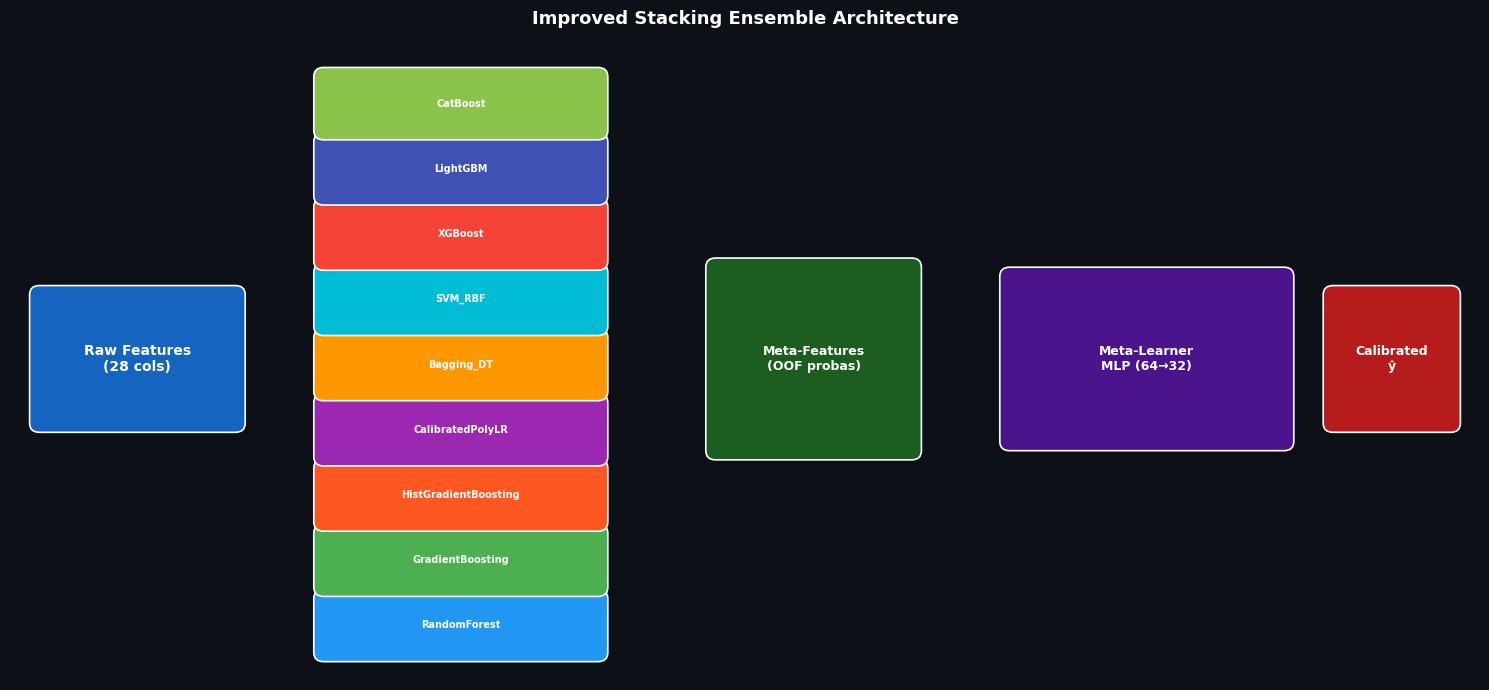

In [51]:
def _dark_ax(ax, fig=None):
    ax.set_facecolor("#161B22")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363D")
    if fig is not None:
        fig.patch.set_facecolor("#0D1117")


def plot_architecture(pipeline):
    fig, ax = plt.subplots(figsize=(15, 7))
    fig.patch.set_facecolor("#0D1117"); ax.set_facecolor("#0D1117"); ax.axis("off")
    ax.set_xlim(0, 15); ax.set_ylim(0, 7)
    def box(x, y, w, h, text, color, fs=8):
        from matplotlib.patches import FancyBboxPatch
        ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
                                    fc=color, ec="white", lw=1.2))
        ax.text(x+w/2, y+h/2, text, ha="center", va="center",
                fontsize=fs, color="white", fontweight="bold")
    n_feat = len(pipeline.feature_names) if pipeline.feature_names else "N"
    box(0.3, 2.8, 2.0, 1.4, f"Raw Features\n({n_feat} cols)", "#1565C0", fs=10)
    names = list(pipeline.base_learners.keys()); n = len(names)
    for i, nm in enumerate(names):
        box(3.2, 0.3+i*(6.4/n), 2.8, 6.2/n-0.1, nm, PALETTE[i%len(PALETTE)], fs=7)
    box(7.2, 2.5, 2.0, 2.0, "Meta-Features\n(OOF probas)", "#1B5E20", fs=9)
    box(10.2, 2.6, 2.8, 1.8, "Meta-Learner\nMLP (64→32)", "#4A148C", fs=9)
    box(13.5, 2.8, 1.2, 1.4, "Calibrated\nŷ", "#B71C1C", fs=9)
    ax.set_title("Improved Stacking Ensemble Architecture",
                 color="white", fontsize=13, pad=10, fontweight="bold")
    plt.tight_layout(); plt.show()

plot_architecture(pipe)

### 14b. Base Learner CV Scores

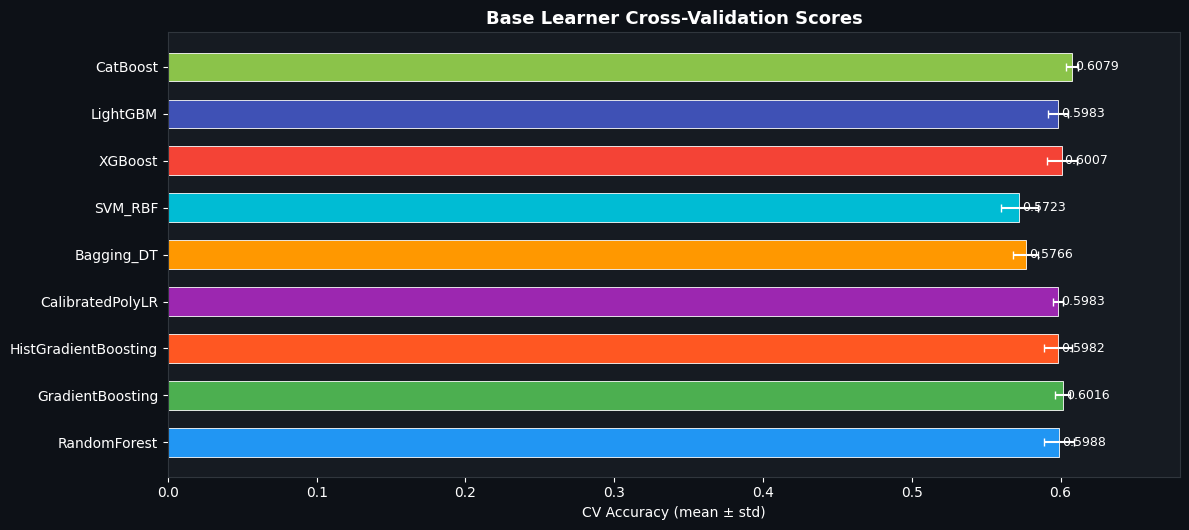

In [52]:
def plot_cv_scores(pipeline):
    if not pipeline.fold_scores: return
    names = [s["model"] for s in pipeline.fold_scores]
    means = [s["cv_mean"] for s in pipeline.fold_scores]
    stds  = [s["cv_std"]  for s in pipeline.fold_scores]
    fig, ax = plt.subplots(figsize=(12, max(5, len(names)*0.6)))
    _dark_ax(ax, fig)
    bars = ax.barh(names, means, xerr=stds, color=PALETTE[:len(names)],
                   edgecolor="white", linewidth=0.6, height=0.6,
                   error_kw={"ecolor": "white", "capsize": 3})
    for bar, m in zip(bars, means):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f"{m:.4f}", va="center", color="white", fontsize=9)
    ax.set_xlabel("CV Accuracy (mean ± std)", color="white", fontsize=10)
    ax.set_title("Base Learner Cross-Validation Scores",
                 color="white", fontsize=13, fontweight="bold")
    ax.set_xlim(0, min(1.0, max(means)+max(stds)+0.06))
    plt.tight_layout(); plt.show()

plot_cv_scores(pipe)

### 14c. Meta-Learner Loss Curve

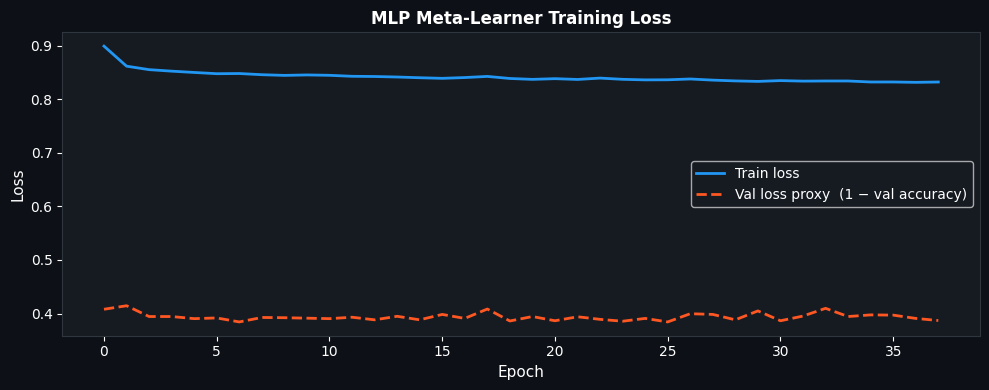

In [53]:
def plot_loss_curve(pipeline):
    ml = pipeline.meta_learner
    if not ml.loss_history: return
    fig, ax = plt.subplots(figsize=(10, 4))
    _dark_ax(ax, fig)
    ax.plot(ml.loss_history, lw=2, color=PALETTE[0], label="Train loss")
    if ml.val_loss_history:
        ax.plot(ml.val_loss_history, lw=2, ls="--", color=PALETTE[2],
                label="Val loss proxy  (1 − val accuracy)")
    ax.set_xlabel("Epoch", color="white", fontsize=11)
    ax.set_ylabel("Loss",  color="white", fontsize=11)
    ax.set_title("MLP Meta-Learner Training Loss",
                 color="white", fontsize=12, fontweight="bold")
    ax.legend(facecolor="#161B22", labelcolor="white", framealpha=0.8)
    plt.tight_layout(); plt.show()

plot_loss_curve(pipe)

### 14d. Confusion Matrix

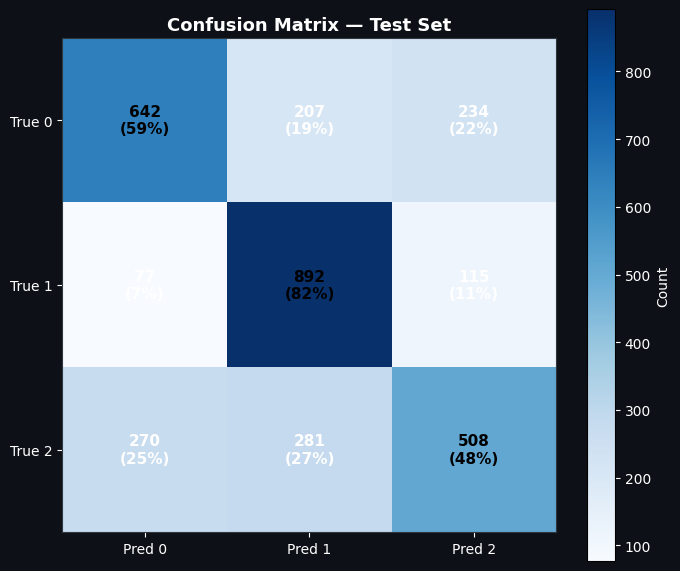

In [54]:
def plot_confusion_matrix(pipeline, split="Test"):
    if split not in pipeline.eval_metrics: return
    cm_data = np.array(pipeline.eval_metrics[split]["confusion_matrix"])
    n       = cm_data.shape[0]
    labels  = [str(c) for c in pipeline.classes_] if pipeline.classes_ is not None \
               else [str(i) for i in range(n)]
    fig, ax = plt.subplots(figsize=(7, 6))
    _dark_ax(ax, fig)
    im   = ax.imshow(cm_data, cmap="Blues")
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
    cbar.set_label("Count", color="white")
    row_sums = cm_data.sum(axis=1, keepdims=True)
    cm_norm  = cm_data / np.where(row_sums==0, 1, row_sums)
    thresh   = cm_data.max() / 2.0
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cm_data[i,j]}\n({cm_norm[i,j]:.0%})",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="white" if cm_data[i,j] < thresh else "black")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels([f"Pred {l}" for l in labels], color="white", fontsize=10)
    ax.set_yticklabels([f"True {l}" for l in labels], color="white", fontsize=10)
    ax.set_title(f"Confusion Matrix — {split} Set",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

plot_confusion_matrix(pipe, "Test")

### 14e. Meta-Learner Weight Heatmap

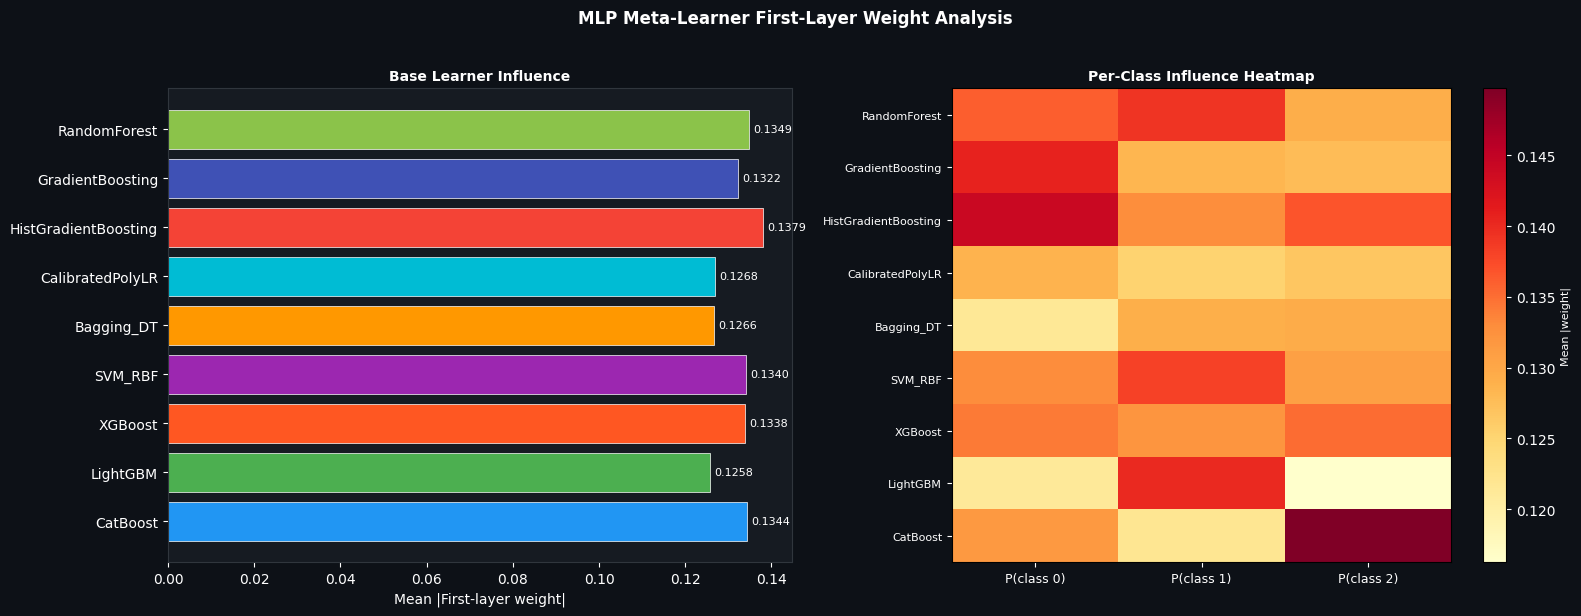

In [55]:
def plot_meta_weight_heatmap(pipeline):
    W = pipeline.meta_learner.W
    if W is None: return
    n_bl = len(pipeline.fitted_base_learners)
    n_cl = pipeline.n_classes_
    if W.shape[0] != n_bl * n_cl: return
    names  = list(pipeline.fitted_base_learners.keys())
    labels = [str(c) for c in pipeline.classes_] if pipeline.classes_ is not None \
              else [str(i) for i in range(n_cl)]
    per_feat_mag = np.abs(W).mean(axis=1)
    W_bl  = per_feat_mag.reshape(n_bl, n_cl)
    W_mag = W_bl.mean(axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor("#0D1117")
    fig.suptitle("MLP Meta-Learner First-Layer Weight Analysis",
                 color="white", fontsize=12, fontweight="bold", y=1.02)
    ax0 = axes[0]; _dark_ax(ax0)
    bars = ax0.barh(names[::-1], W_mag[::-1], color=PALETTE[:n_bl],
                    edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, W_mag[::-1]):
        ax0.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", color="white", fontsize=8)
    ax0.set_xlabel("Mean |First-layer weight|", color="white", fontsize=10)
    ax0.set_title("Base Learner Influence", color="white", fontsize=10, fontweight="bold")
    ax1 = axes[1]
    im   = ax1.imshow(W_bl, aspect="auto", cmap="YlOrRd")
    cbar = plt.colorbar(im, ax=ax1)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
    cbar.set_label("Mean |weight|", color="white", fontsize=8)
    ax1.set_xticks(range(n_cl))
    ax1.set_xticklabels([f"P(class {l})" for l in labels], color="white", fontsize=9)
    ax1.set_yticks(range(n_bl)); ax1.set_yticklabels(names, color="white", fontsize=8)
    ax1.set_title("Per-Class Influence Heatmap", color="white", fontsize=10, fontweight="bold")
    ax1.tick_params(colors="white")
    plt.tight_layout(); plt.show()

plot_meta_weight_heatmap(pipe)

### 14f. Learning Curve

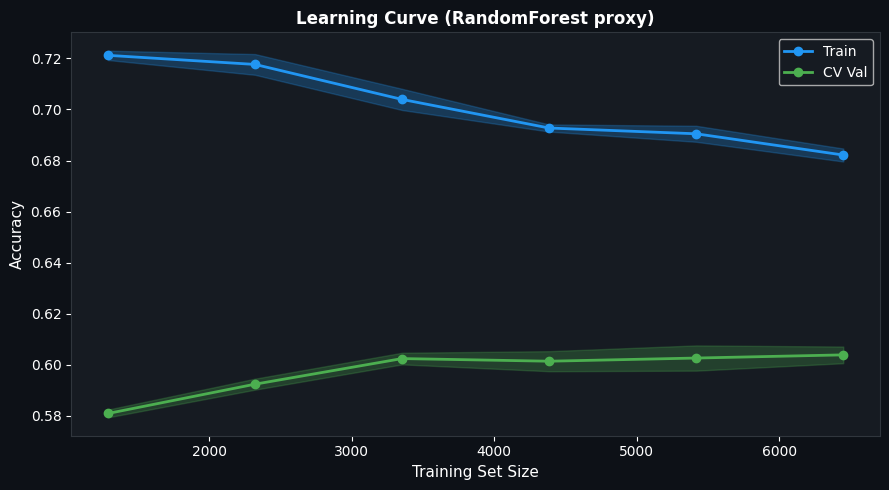

In [56]:
def plot_learning_curve(pipeline):
    Xs  = pipeline.scaler.transform(X_tr) if pipeline.scale_features else X_tr
    clf = RandomForestClassifier(n_estimators=60 if pipeline.fast else 100,
                                  max_depth=10, min_samples_leaf=4,
                                  random_state=42, n_jobs=-1)
    sizes, tr_sc, va_sc = learning_curve(
        clf, Xs, y_tr, cv=3, scoring="accuracy",
        train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1)
    fig, ax = plt.subplots(figsize=(9, 5))
    _dark_ax(ax, fig)
    tm, ts = tr_sc.mean(1), tr_sc.std(1)
    vm, vs = va_sc.mean(1), va_sc.std(1)
    ax.plot(sizes, tm, "o-", color=PALETTE[0], lw=2, label="Train")
    ax.fill_between(sizes, tm-ts, tm+ts, alpha=0.25, color=PALETTE[0])
    ax.plot(sizes, vm, "o-", color=PALETTE[1], lw=2, label="CV Val")
    ax.fill_between(sizes, vm-vs, vm+vs, alpha=0.25, color=PALETTE[1])
    ax.set_xlabel("Training Set Size", color="white", fontsize=11)
    ax.set_ylabel("Accuracy",          color="white", fontsize=11)
    ax.set_title("Learning Curve (RandomForest proxy)",
                 color="white", fontsize=12, fontweight="bold")
    ax.legend(facecolor="#161B22", labelcolor="white", framealpha=0.8)
    plt.tight_layout(); plt.show()

plot_learning_curve(pipe)

### 14g. Calibration — Before vs After

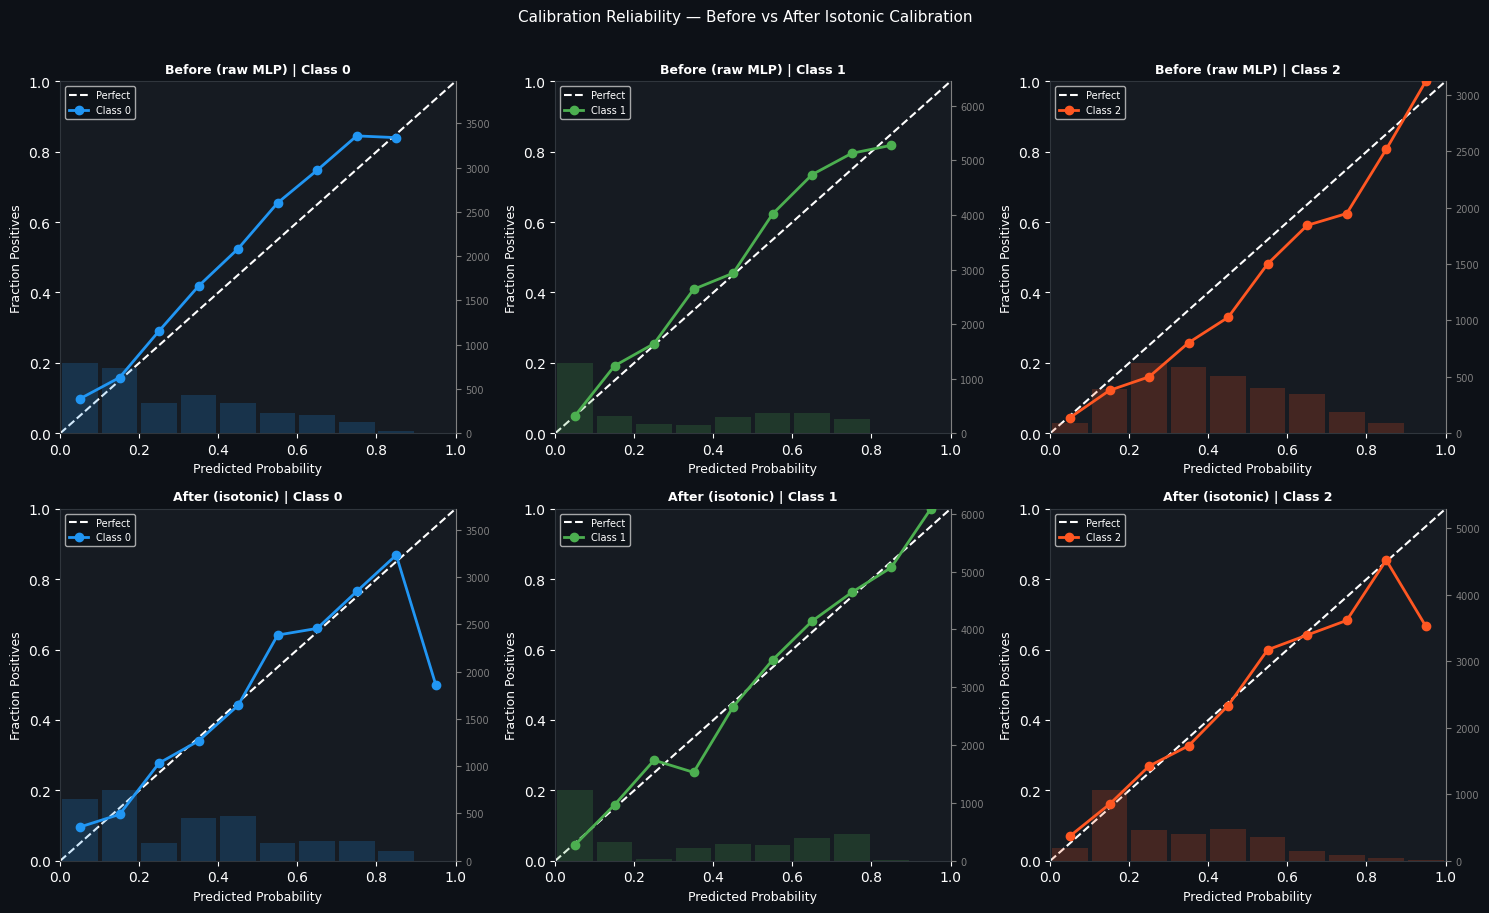

In [57]:
def _reliability_diagram(ax, proba_col, y_bin, color, label, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1); mids = (bins[:-1]+bins[1:])/2
    frac_pos, counts = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (proba_col>=lo)&(proba_col<hi)
        frac_pos.append(y_bin[mask].mean() if mask.sum()>0 else np.nan)
        counts.append(int(mask.sum()))
    ax.plot(mids, frac_pos, "o-", color=color, lw=2, label=label, zorder=3)
    return counts


def plot_calibration_comparison(pipeline, X_test, y_test, raw_proba):
    cal_proba = pipeline.predict_proba(X_test)
    n_cl      = pipeline.n_classes_
    labels    = [str(c) for c in pipeline.classes_] if pipeline.classes_ is not None \
                else [str(i) for i in range(n_cl)]
    fig, axes = plt.subplots(2, n_cl, figsize=(5*n_cl, 9), squeeze=False)
    fig.patch.set_facecolor("#0D1117")
    fig.suptitle("Calibration Reliability — Before vs After Isotonic Calibration",
                 color="white", fontsize=11, y=1.01)
    for row, (row_lbl, proba) in enumerate(
            zip(["Before (raw MLP)", "After (isotonic)"], [raw_proba, cal_proba])):
        for c in range(n_cl):
            ax = axes[row][c]; _dark_ax(ax)
            y_bin = (y_test==c).astype(int)
            ax.plot([0,1],[0,1],"w--",lw=1.5,label="Perfect",zorder=2)
            counts = _reliability_diagram(ax, proba[:,c], y_bin,
                                          PALETTE[c%len(PALETTE)], f"Class {labels[c]}")
            ax2 = ax.twinx()
            bins = np.linspace(0,1,11); mids=(bins[:-1]+bins[1:])/2
            ax2.bar(mids, counts, width=0.09, alpha=0.2, color=PALETTE[c%len(PALETTE)])
            ax2.set_ylim(0, max(counts)*5 if max(counts)>0 else 1)
            ax2.tick_params(colors="gray", labelsize=7)
            for sp in ["top","left","bottom"]: ax2.spines[sp].set_visible(False)
            ax2.spines["right"].set_edgecolor("gray")
            ax.set_xlim(0,1); ax.set_ylim(0,1)
            ax.set_xlabel("Predicted Probability", color="white", fontsize=9)
            ax.set_ylabel("Fraction Positives",    color="white", fontsize=9)
            ax.set_title(f"{row_lbl} | Class {labels[c]}",
                         color="white", fontsize=9, fontweight="bold")
            ax.legend(facecolor="#0D1117", labelcolor="white", fontsize=7, loc="upper left")
    plt.tight_layout(); plt.show()


if RUN_CALIBRATION:
    plot_calibration_comparison(pipe, X_te, y_te, raw_proba_test)
else:
    print("Calibration disabled — skipping before/after chart.")

### 14h. Permutation Feature Importance

2026-04-10 23:11:36  [INFO    ]  [Feature Importance] Computing permutation importance …
2026-04-10 23:11:36  [INFO    ]  
[Permutation Importance] n_repeats=10 …


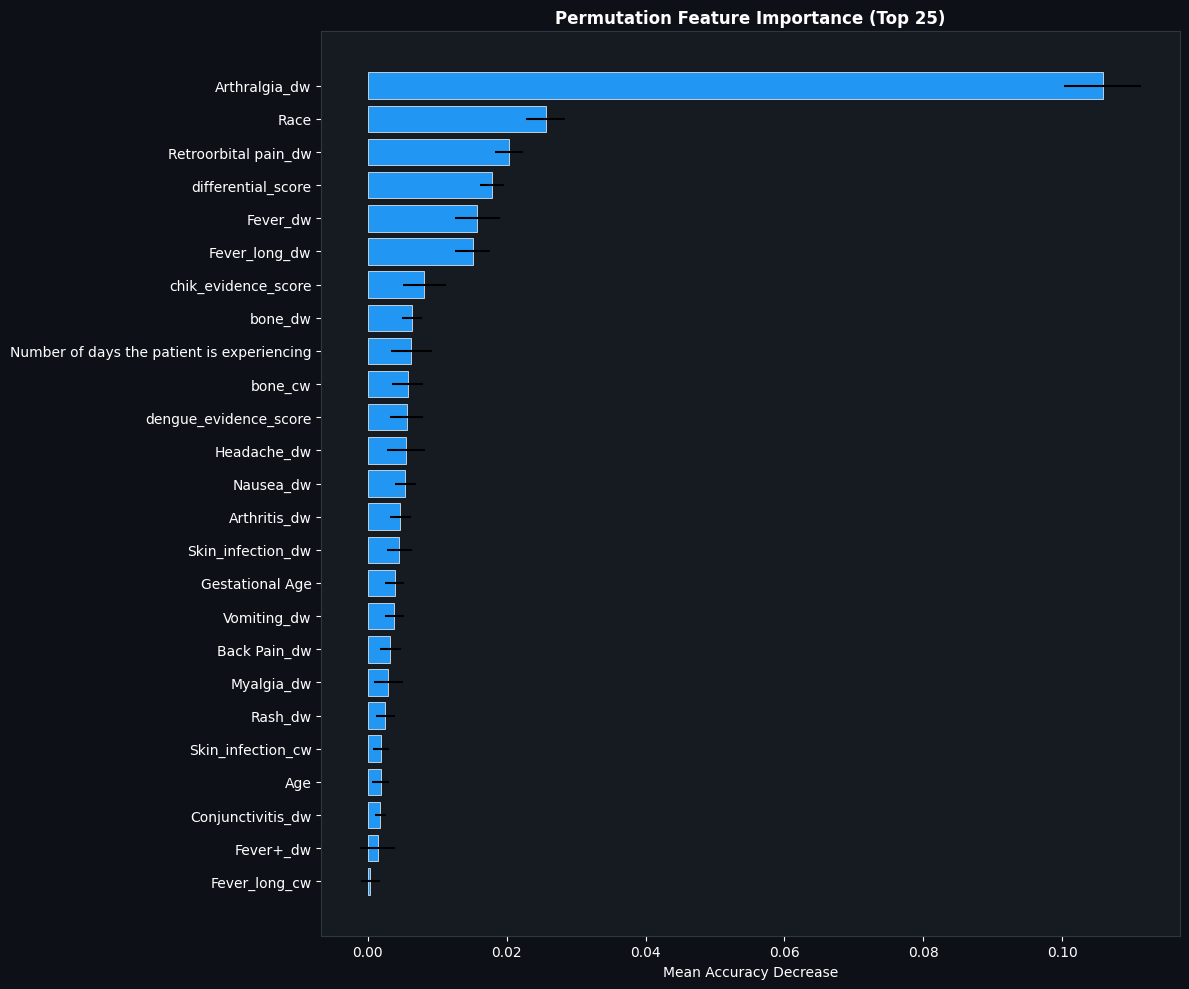

In [58]:
log.info("[Feature Importance] Computing permutation importance …")
pipe.compute_permutation_importance(X_te, y_te, n_repeats=5 if FAST_MODE else 10)

def plot_feature_importance(pipeline, feature_names):
    if pipeline.perm_importances is None: return
    imp     = pipeline.perm_importances
    imp_std = pipeline.perm_importances_std if pipeline.perm_importances_std is not None \
              else np.zeros_like(imp)
    top_n = min(25, len(feature_names))
    idx   = np.argsort(imp)[::-1][:top_n]
    names = [feature_names[i] for i in idx]
    vals  = imp[idx]; errs = imp_std[idx]
    fig, ax = plt.subplots(figsize=(12, max(6, top_n*0.4)))
    _dark_ax(ax, fig)
    ax.barh(names[::-1], vals[::-1], xerr=errs[::-1],
            edgecolor="white", linewidth=0.5, color=PALETTE[0])
    ax.set_title(f"Permutation Feature Importance (Top {top_n})",
                 color="white", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Accuracy Decrease", color="white")
    plt.tight_layout(); plt.show()

plot_feature_importance(pipe, feat_cols)

## 15. Save & JSON Log

Saves the fitted pipeline as a `.pkl` file and exports all metrics, fold scores, tuned hyperparameters, and ablation results to a structured JSON log.

In [59]:
model_path = paths["model"] / f"stacking_improved_{TS}.pkl"
pipe.save(model_path)

json_log = {
    "timestamp":        TS,
    "split_strategy":   SPLIT_STRATEGY,
    "n_base_learners":  len(pipe.base_learners),
    "base_learners":    list(pipe.base_learners.keys()),
    "meta_type":        "MLPClassifier(64,32)",
    "meta_lr":          pipe.meta_lr,
    "meta_epochs":      pipe.meta_epochs,
    "cv_folds":         pipe.n_splits,
    "feat_mask_frac":   pipe.feat_mask_frac,
    "use_smote":        pipe.use_smote,
    "class2_weight":    pipe.class2_weight,
    "calibration":      RUN_CALIBRATION,
    "tuned_params":     tuned_params,
    "fold_scores":      pipe.fold_scores,
    "train_metrics":    pipe.train_metrics,
    "eval_metrics":     pipe.eval_metrics,
    "perm_importances": pipe.perm_importances.tolist()
                        if pipe.perm_importances is not None else None,
    "bootstrap_coverage": {
        name: int(len(np.unique(idx)))
        for name, idx in pipe.bootstrap_indices.items()
    },
    "ablation_results": ablation_results,
}

log_path = paths["logs"] / f"results_{TS}.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(json_log, f, indent=2)

print(f"Model   → {model_path}")
print(f"JSON log → {log_path}")

# Reload demo
# pipe_loaded = StackingPipeline.load(model_path)
# pipe_loaded.predict(X_te[:3])

2026-04-10 23:13:09  [INFO    ]    Model saved → C:\Users\Quoc Thai\Downloads\ML\HealthcareSystemForDengueFever\artifacts\model\stacking_improved_20260410_230832.pkl
Model   → C:\Users\Quoc Thai\Downloads\ML\HealthcareSystemForDengueFever\artifacts\model\stacking_improved_20260410_230832.pkl
JSON log → C:\Users\Quoc Thai\Downloads\ML\HealthcareSystemForDengueFever\artifacts\logs\results_20260410_230832.json
